In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages

In [21]:
# Path to your results file
csv_path = r"G:\Shared drives\Kerlin lab shared\Manuscripts\Reload Paper\second submission\figures_etc\ReLOAD_spot_analysis\ReLOAD_spots_plus_roisum\results.csv"

# Load results
df = pd.read_csv(csv_path)

# Sort by cx_corrected (ascending)
sd = df.sort_values(by="cx_corrected", ascending=True)

In [22]:
fwhm_scan=sd['h_sigma']*2*np.sqrt(2*np.log(2))*2.2  #FWHM in scan axis um, this was already calculated in the workup script
fwhm_loop=sd['v_sigma']*2*np.sqrt(2*np.log(2))*2.2 #FWHM in loop axis um

amp_scan=sd['h_amp'] #scan axis fit amplitude 
amp_loop=sd['v_amp'] #loop axis fit amplitude should be ~ the same
roi_sum=sd['roi_sum']

pos=sd['cx_corrected'] #raw pix position data
pos_cor = ((pos - pos[22]) * 2.2) #corrected to um based on 2.2 um pixel size

Plot saved as PDF to G:\Shared drives\Kerlin lab shared\Manuscripts\Reload Paper\second submission\figures_etc\ReLOAD_spot_analysis\ReLOAD_spots_plus_roisum\updated_intensity2.pdf


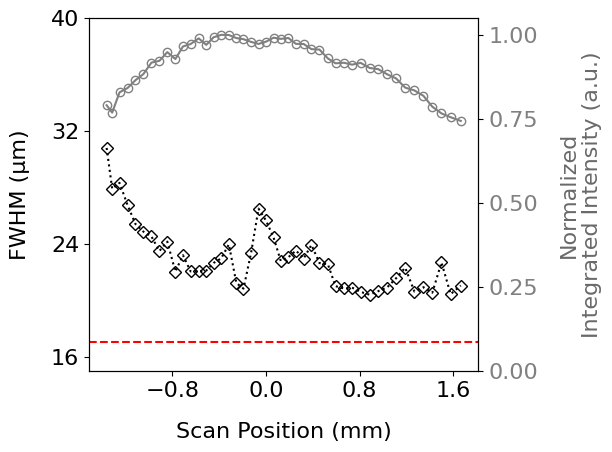

In [38]:
plt.rcParams.update({'font.size': 16})
plt.rcParams['axes.labelpad'] = 15
fig, ax1 = plt.subplots()

# -----------------------------
# PLOT FWHM CURVES (LEFT AXIS)
# -----------------------------
#l1, = ax1.plot(pos_cor/1000, fwhm_loop, marker='D', color='black',
               #linestyle='-', label='loop axis (FWHM)', fillstyle='none')

l2, = ax1.plot(pos_cor/1000, fwhm_scan, marker='D', color='black',
               linestyle='dotted', label='scan axis (FWHM)', fillstyle='none')

dl_spot = ((max(sd['cx_corrected']) - min(sd['cx_corrected'])) * 2.2) / 177

# diffraction limited spot line
l3 = ax1.axhline(dl_spot, color='red', linestyle='--', linewidth=1.5,
                 label='diffraction-limited spot size')

ax1.set_xlabel("Scan Position (mm)")
ax1.set_ylabel("FWHM (µm)", color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.yaxis.set_major_locator(MaxNLocator(nbins=4))
ax1.set_ylim(15,40)

ax2 = ax1.twinx()

l4, = ax2.plot(pos_cor/1000, (roi_sum / max(roi_sum)), marker='o',
               color='gray', linestyle='-', fillstyle='none',
               label='normalized intensity')

ax2.set_ylabel("Normalized\nIntegrated Intensity (a.u.)", color='dimgray')
ax2.tick_params(axis='y', labelcolor='grey')
ax2.set_ylim(0,1.05)



top_handles = [l1, l2]     # FWHM curves
bottom_handles = [l3, l4]  # DL line + intensity
handles = top_handles + bottom_handles
labels = [h.get_label() for h in handles]

#fig.legend(handles, labels,
           #loc='center',
          # bbox_to_anchor=(0.5, 1.05),
           #prop={'size': 12},
          # ncol=2,             # 2 columns → produces stacked layout
           #columnspacing=1.5,
           #frameon=False)


ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=5))
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=5))

fig.tight_layout()

save_path = r"G:\Shared drives\Kerlin lab shared\Manuscripts\Reload Paper\second submission\figures_etc\ReLOAD_spot_analysis\ReLOAD_spots_plus_roisum\updated_intensity2.pdf"

with PdfPages(save_path) as pdf:
    pdf.savefig(fig, bbox_inches='tight', pad_inches=0.05, dpi=600)

print(f"Plot saved as PDF to {save_path}")

plt.show()


In [184]:
fwhm_scan[22]

10.787381925316382

In [39]:
132/177

0.7457627118644068

In [190]:
23/26

0.8846153846153846

In [191]:
132/26

5.076923076923077

In [192]:
389.18/15

25.945333333333334

In [10]:
conv_fac=31.1/20 #pix/um
FOV=301.6/conv_fac
dl_spot_refscope=FOV/50
dl_spot_refscope

3.8790996784565914

In [11]:
dl_spot=((max(sd['cx_corrected'])-min(sd['cx_corrected']))*2.2)/177

In [12]:
dl_spot

17.08917744275878